# Isolation Forest

Multivariate detector — looks at all 28 features together, catches
unusual COMBINATIONS that a single-metric check like Z-Score would miss
(e.g. slow_query_storm: latency up + cpu down at the same time).

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score

ML_DIR = Path("../ml_models")

In [2]:
X_train = np.load(ML_DIR / "X_train.npy")
X_test  = np.load(ML_DIR / "X_test.npy")
y_train = np.load(ML_DIR / "y_train.npy")
y_test  = np.load(ML_DIR / "y_test.npy")

with open(ML_DIR / "feature_cols.json") as f:
    feature_cols = json.load(f)

print("Loaded:", X_train.shape, X_test.shape)

Loaded: (12776, 28) (3195, 28)


## Design decision: train on NORMAL data only

Isolation Forest doesn't technically need labels — it's built to work
without them. But since we HAVE labeled data, we can use it smartly: we
show the model only the normal readings during training, so it learns a
clean picture of what "normal" looks like, without confusing it with
anomalies mixed into its training data.

This is called semi-supervised training — the algorithm itself is
unsupervised, but we use our labels to curate a clean training set.

In [3]:
X_train_normal = X_train[y_train == 0]

print(f"Training rows: {len(X_train)} total → {len(X_train_normal)} normal-only")
print(f"Removed {len(X_train) - len(X_train_normal)} anomalous rows from training")

Training rows: 12776 total → 10266 normal-only
Removed 2510 anomalous rows from training


## Training the forest

n_estimators: how many random "fence-building" trees to grow. More trees
= more stable, averaged-out score, at the cost of more computation.
200 is a solid default for this data size.

contamination: a rough guess of what fraction of data is anomalous.
sklearn uses this internally to set a default yes/no cutoff — but we're
going to ignore that and do our own threshold search instead, exactly
like we did for Z-Score. So this value isn't critical here.

random_state: fixes the randomness so results are reproducible — running
this cell twice gives the identical forest, not a slightly different one
each time.

In [4]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    random_state=42,
    n_jobs=-1,   # use all CPU cores
)
model.fit(X_train_normal)

print("Model trained on", len(X_train_normal), "normal readings")

Model trained on 10266 normal readings


## Getting a continuous anomaly score

Instead of asking the model for a plain yes/no, we ask for a raw SCORE
using decision_function() — a number where LOWER (more negative) means
MORE anomalous, and higher means more normal.

This gives us the same kind of continuous number we had with z-scores,
so we can do the exact same threshold-sweep approach as Step 3.

In [5]:
train_scores = model.decision_function(X_train)
test_scores  = model.decision_function(X_test)

print("Train score range:", train_scores.min(), "to", train_scores.max())
print("Test score range: ", test_scores.min(), "to", test_scores.max())

Train score range: -0.3005346467246795 to 0.07889455761662795
Test score range:  -0.20260164555301535 to 0.07776861072039815


In [6]:
def iforest_predict(scores: np.ndarray, threshold: float) -> np.ndarray:
    """Flag as anomaly if the score is BELOW threshold (more negative = more unusual)."""
    return (scores < threshold).astype(int)

thresholds = np.linspace(train_scores.min(), train_scores.max(), 40)
results = []

for t in thresholds:
    y_pred = iforest_predict(train_scores, threshold=t)
    results.append({
        "threshold": round(t, 4),
        "precision": precision_score(y_train, y_pred, zero_division=0),
        "recall":    recall_score(y_train, y_pred, zero_division=0),
        "f1":        f1_score(y_train, y_pred, zero_division=0),
    })

results_df = pd.DataFrame(results)
results_df

,threshold,precision,recall,f1
0,-0.3005,0.000000,0.000000,0.000000
1,-0.2908,0.000000,0.000000,0.000000
2,-0.2811,0.000000,0.000000,0.000000
3,-0.2713,0.000000,0.000000,0.000000
4,-0.2616,0.000000,0.000000,0.000000
5,-0.2519,0.200000,0.000398,0.000795
6,-0.2422,0.500000,0.001594,0.003177
7,-0.2324,0.647059,0.004382,0.008706
8,-0.2227,0.764706,0.010359,0.020440
9,-0.2130,0.793103,0.018327,0.035826


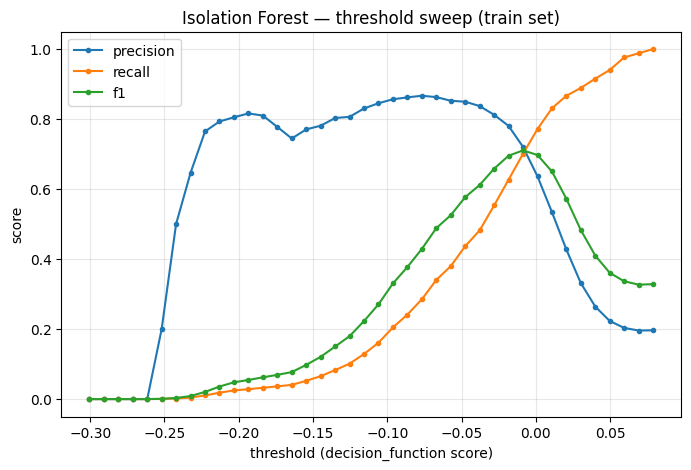

Best threshold: -0.0087  (F1=0.710)


In [7]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["threshold"], results_df["precision"], label="precision", marker="o", markersize=3)
plt.plot(results_df["threshold"], results_df["recall"],    label="recall",    marker="o", markersize=3)
plt.plot(results_df["threshold"], results_df["f1"],        label="f1",       marker="o", markersize=3)
plt.xlabel("threshold (decision_function score)")
plt.ylabel("score")
plt.title("Isolation Forest — threshold sweep (train set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_row = results_df.loc[results_df["f1"].idxmax()]
print(f"Best threshold: {best_row['threshold']}  (F1={best_row['f1']:.3f})")

In [8]:
best_threshold = float(best_row["threshold"])
y_pred_test = iforest_predict(test_scores, threshold=best_threshold)

print(f"Test set results (threshold={best_threshold}):")
print(f"  Precision: {precision_score(y_test, y_pred_test):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_test):.3f}")
print(f"  F1 score:  {f1_score(y_test, y_pred_test):.3f}")

Test set results (threshold=-0.0087):
  Precision: 0.818
  Recall:    0.698
  F1 score:  0.753


## Saving the model

Unlike Z-Score (whose entire "model" was one number), Isolation Forest
has actually LEARNED something — hundreds of trees with real structure.
We need to save the whole model object to disk, not just a threshold.

In [9]:
import joblib

joblib.dump(model, ML_DIR / "iforest_model.joblib")

config = {
    "detector": "isolation_forest",
    "threshold": best_threshold,
    "n_estimators": 200,
    "trained_on": "X_train_normal (normal rows only)",
}
with open(ML_DIR / "iforest_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved iforest_model.joblib and iforest_config.json")
print(config)

Saved iforest_model.joblib and iforest_config.json
{'detector': 'isolation_forest', 'threshold': -0.0087, 'n_estimators': 200, 'trained_on': 'X_train_normal (normal rows only)'}
